In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random

In [29]:
%matplotlib inline

In [3]:
data = pd.read_csv('../datasets/acc_data.csv')
data.head()

,TIMESTAMP,INDEX,ACC_X,ACC_Y,ACC_Z,GESTURE
0,2.024110e+13,1,-365,26,905,1
1,2.024110e+13,1,-108,42,1007,1
2,2.024110e+13,1,-205,81,1003,1
3,2.024110e+13,1,-166,34,1003,1
4,2.024110e+13,1,-139,65,983,1


In [5]:
fileName = "../datasets/acc_data"
file1 = pd.read_csv(f'{fileName}.csv')
file1[' INDEX'] = (file1[' INDEX'] != file1[' INDEX'].shift()).cumsum()
file1.to_csv(f'{fileName}_updated.csv', index=False)
print(f"{fileName}_updated.csv created successfully!")

../datasets/acc_data_updated.csv created successfully!


In [7]:
data = pd.read_csv('../datasets/acc_data_updated.csv')
data.head()

,TIMESTAMP,INDEX,ACC_X,ACC_Y,ACC_Z,GESTURE
0,2.024110e+13,1,-365,26,905,1
1,2.024110e+13,1,-108,42,1007,1
2,2.024110e+13,1,-205,81,1003,1
3,2.024110e+13,1,-166,34,1003,1
4,2.024110e+13,1,-139,65,983,1


In [ ]:
data.shape

(200860, 6)

In [9]:
data.columns = data.columns.str.strip()

In [10]:
gestures = data['GESTURE'].unique()
gestures

array([1, 2])

In [11]:
n_samples = 100
# n_gestures_to_plot = 100
# fig, axes = plt.subplots(n_gestures_to_plot // 10, 10, figsize=(20, n_gestures_to_plot //5))
# axes = axes.flatten()

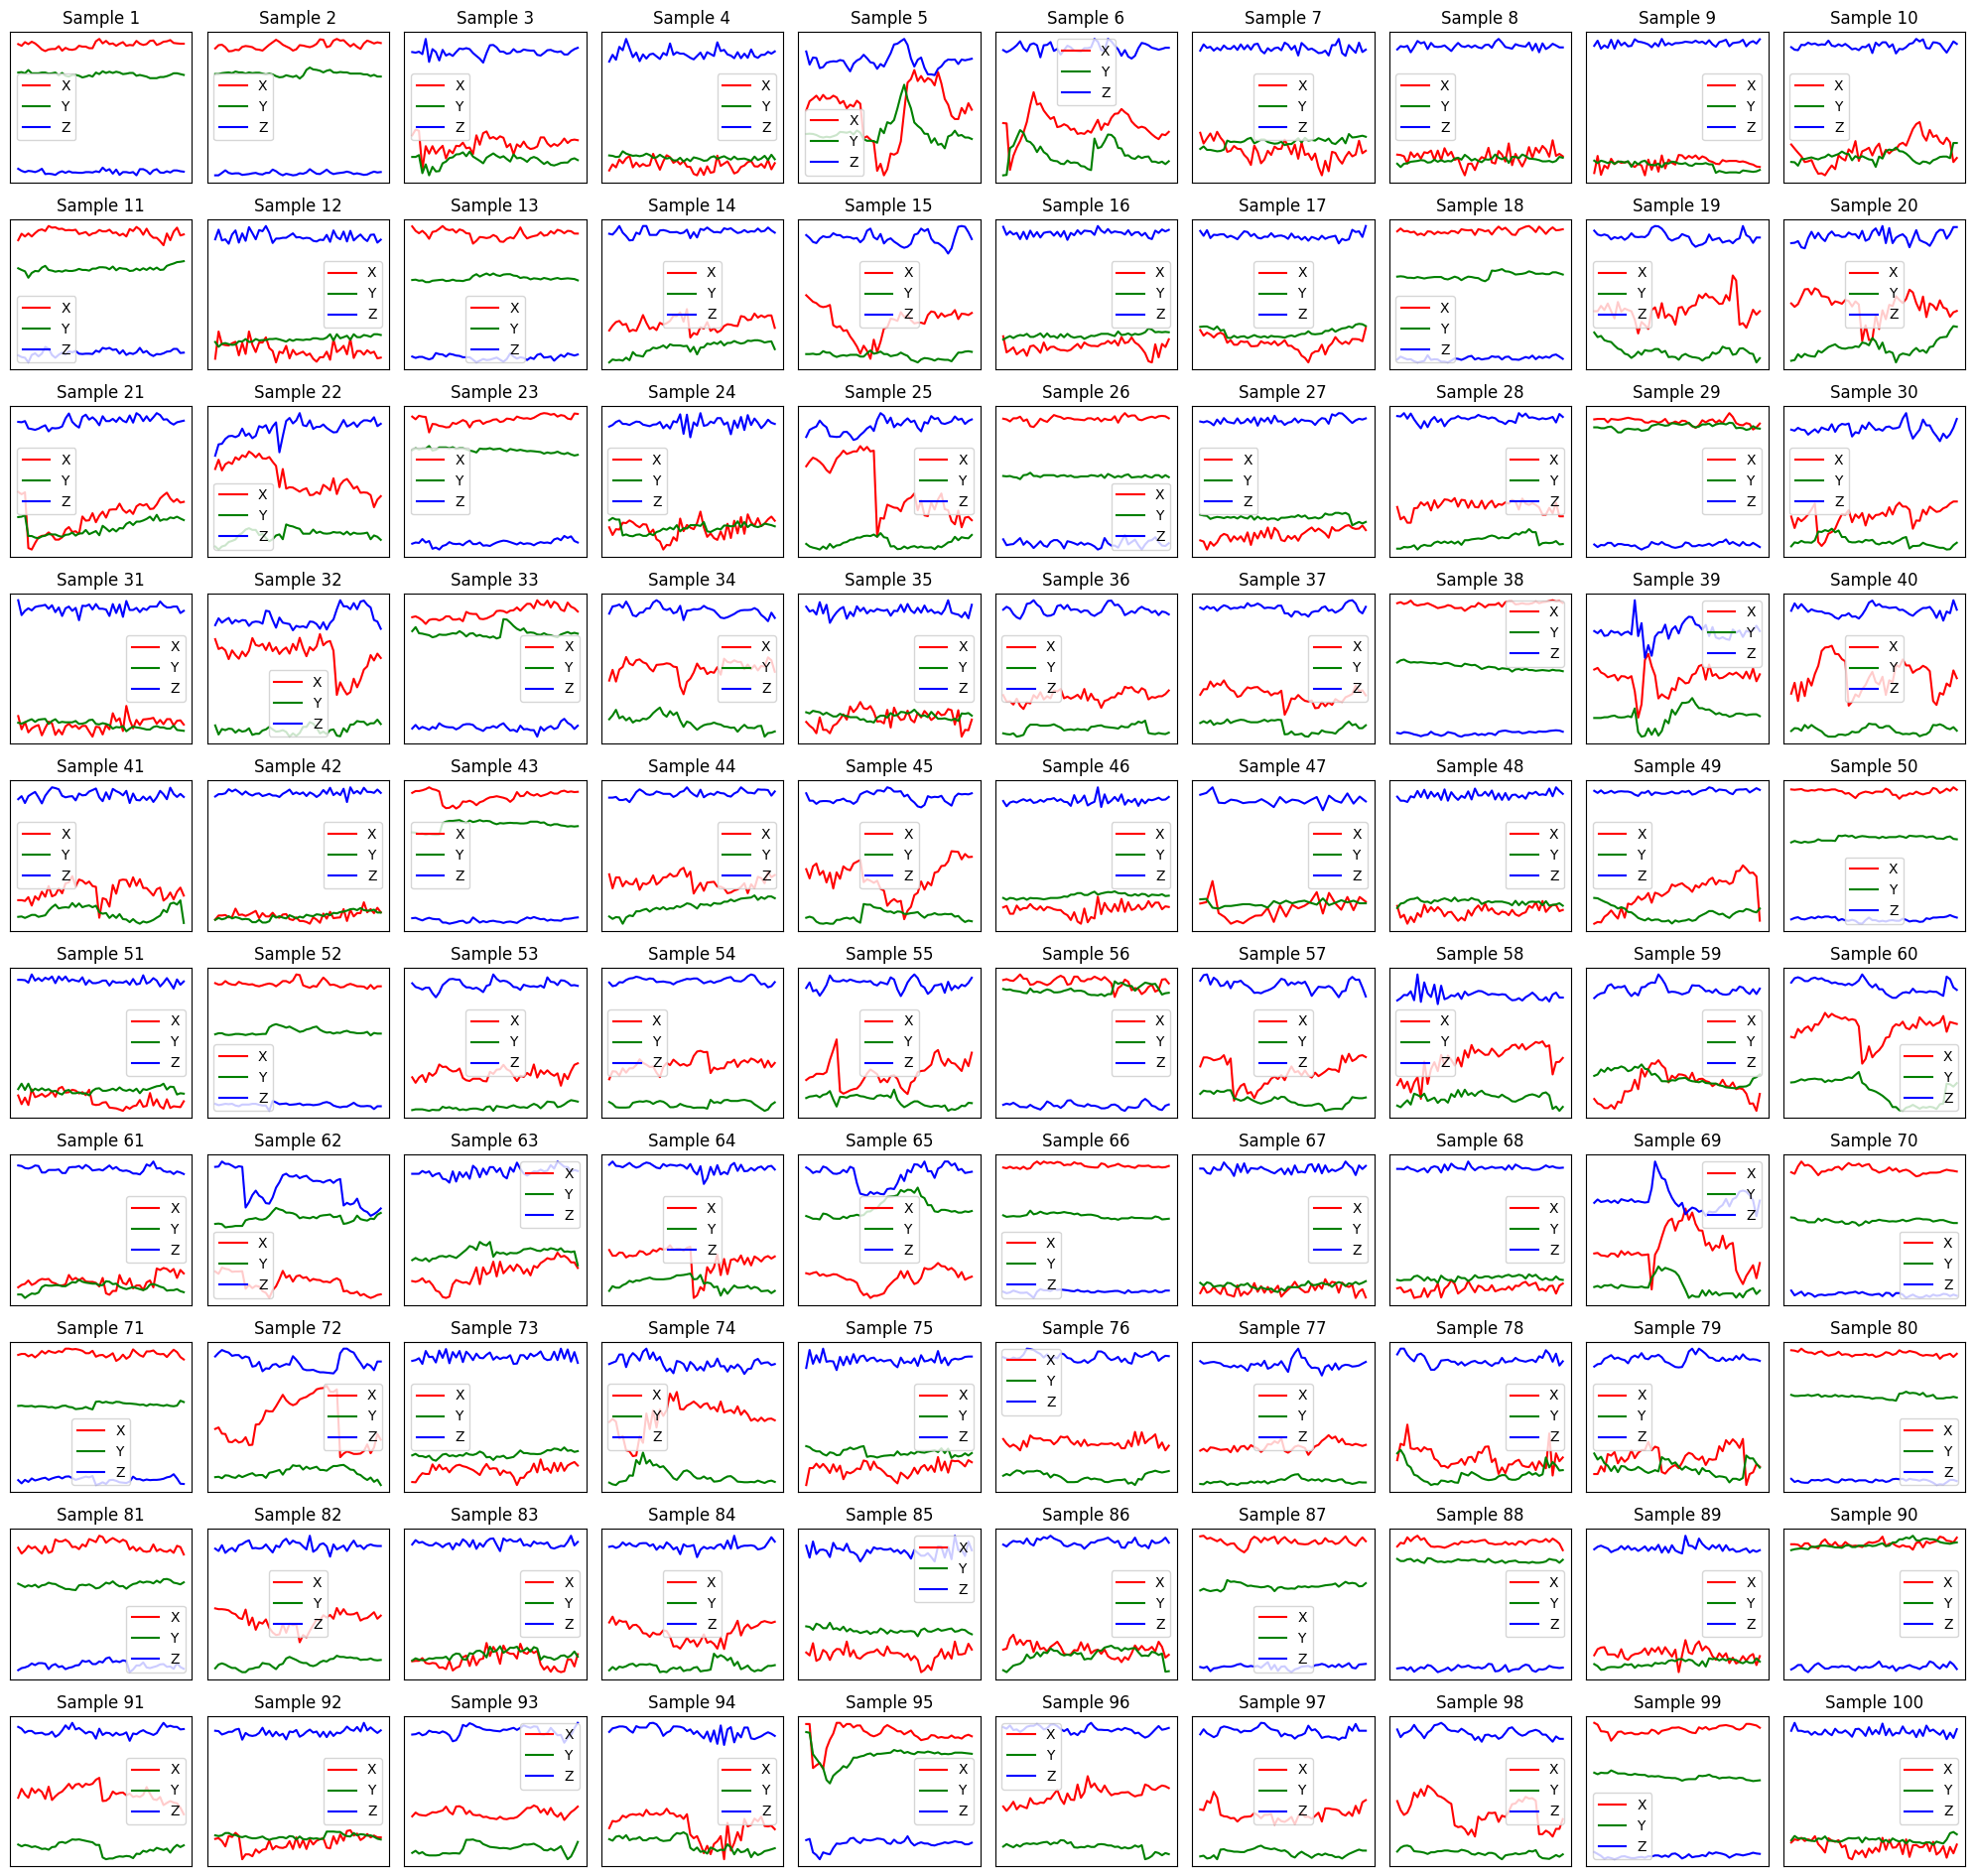

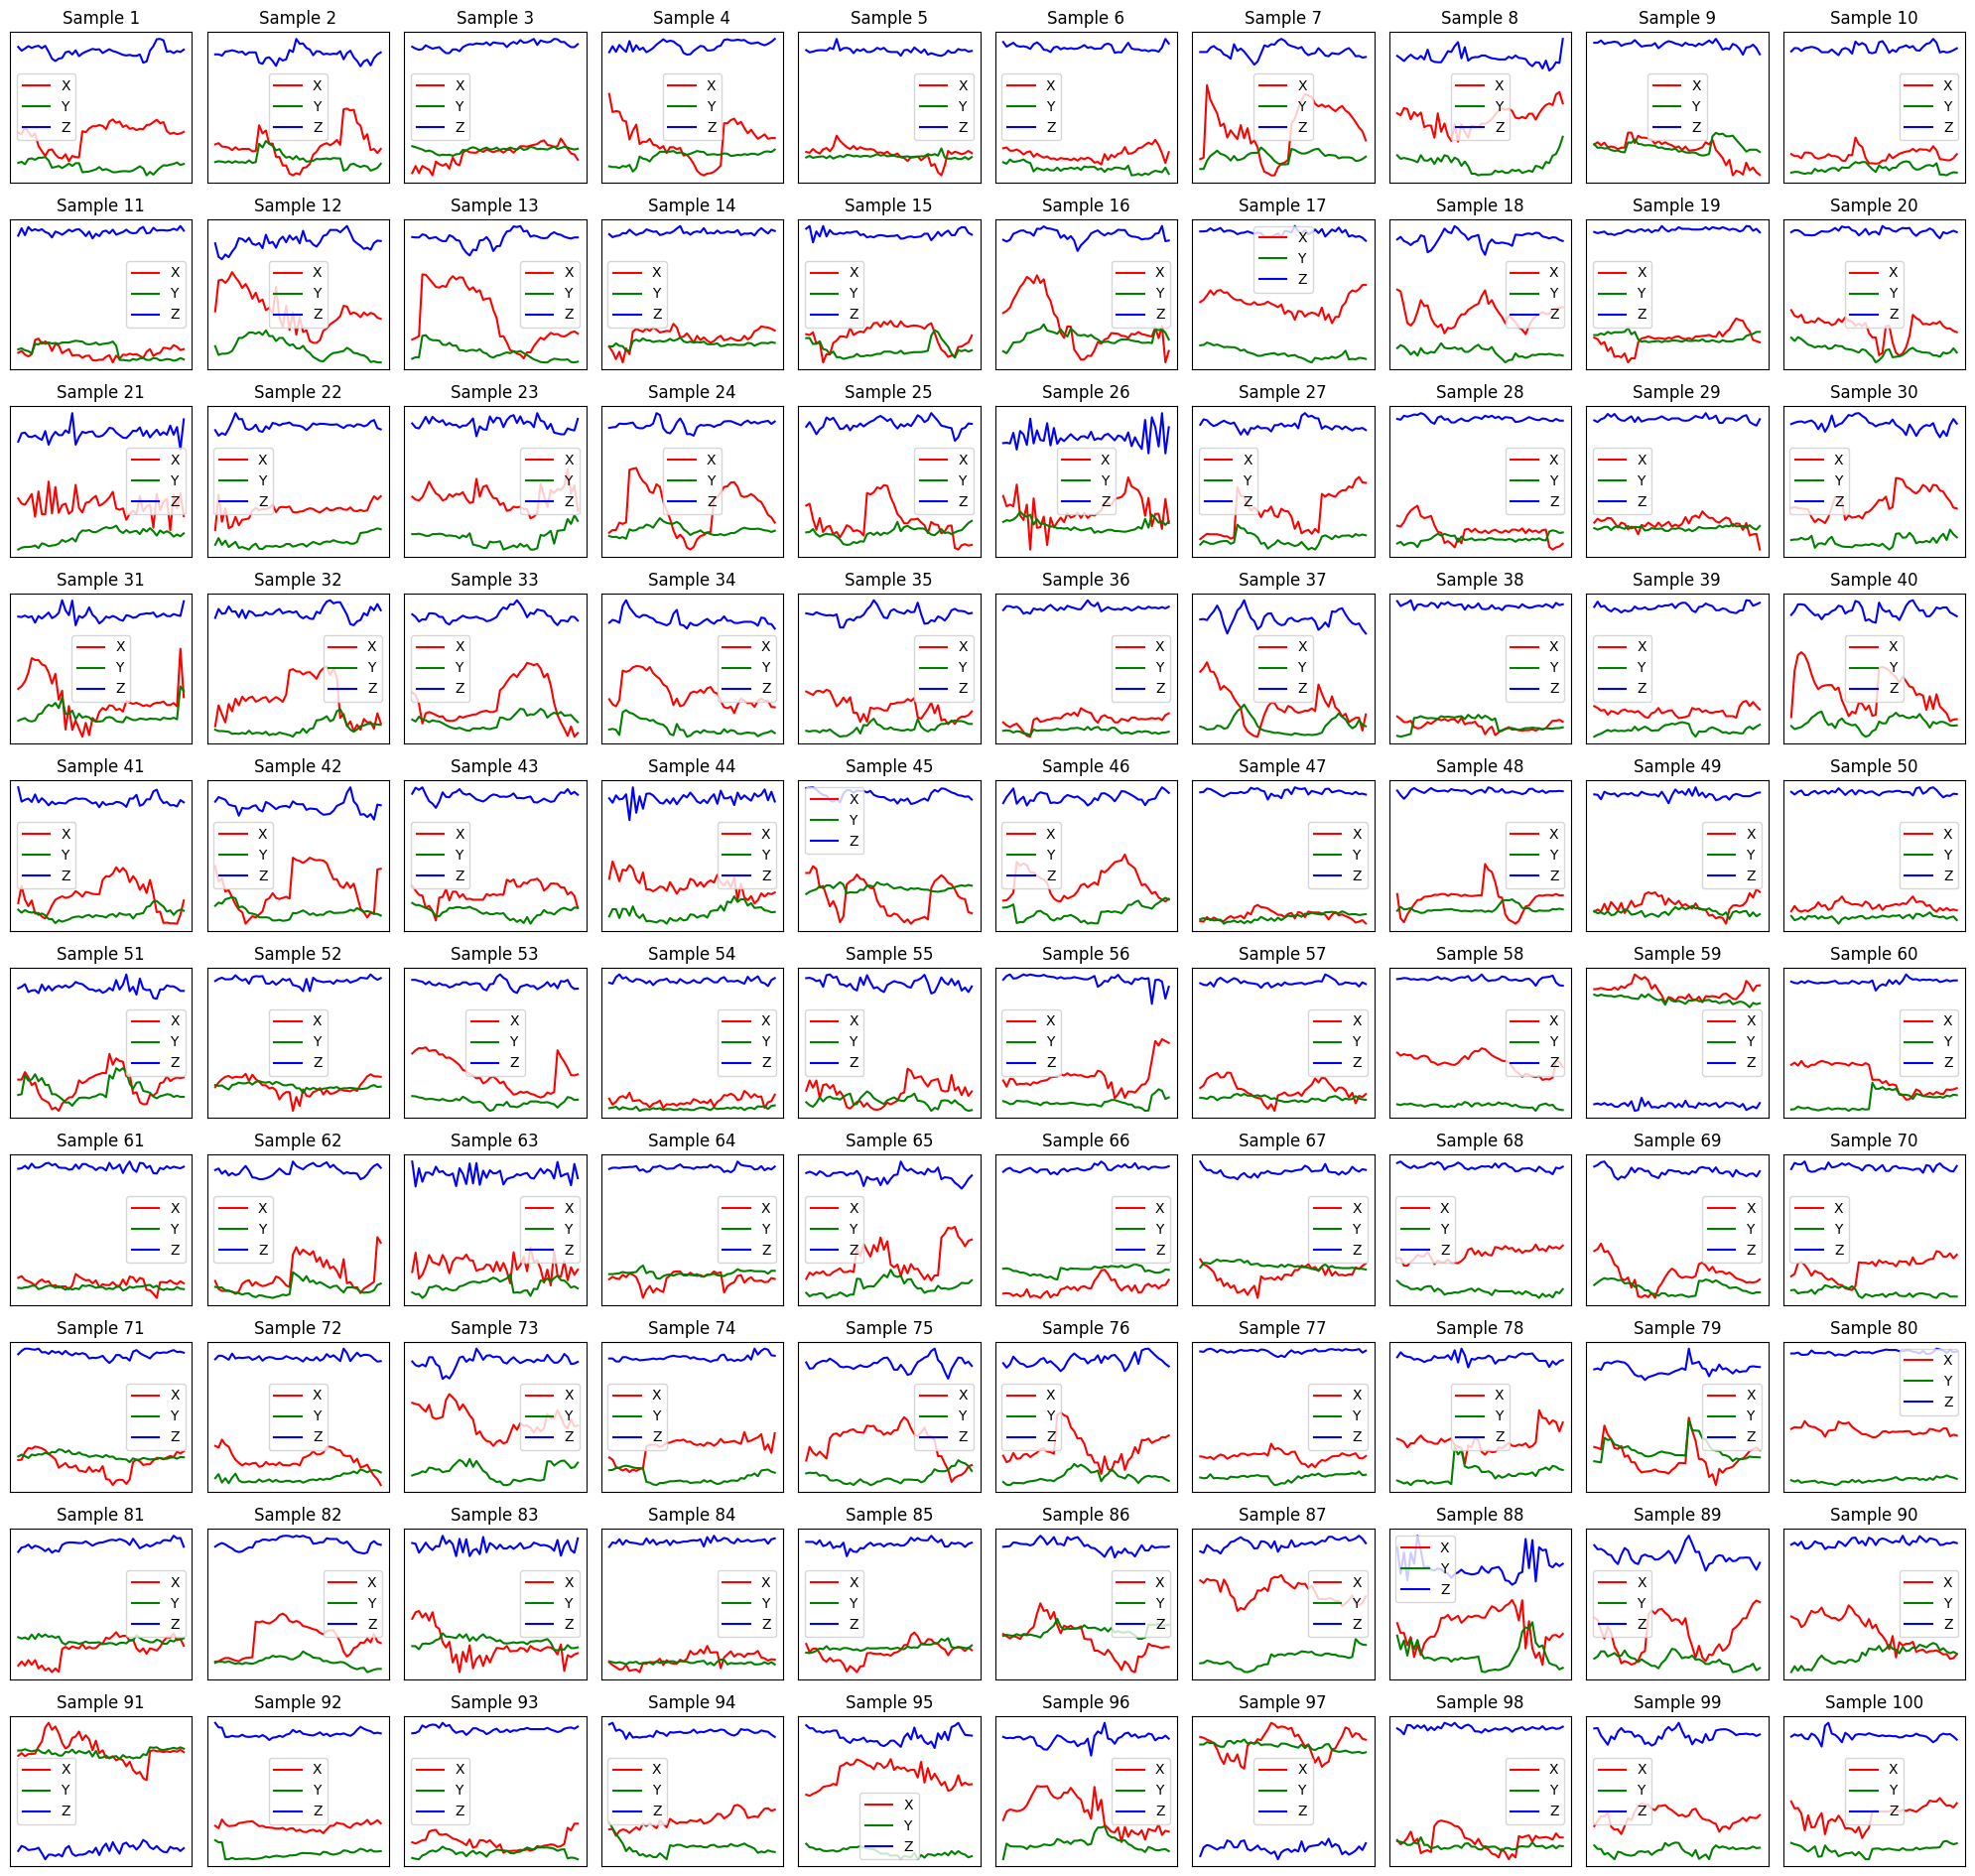

In [12]:
for gesture in gestures:
    label_data = data[data['GESTURE'] == gesture]
    random_starts = random.sample(range(0, len(label_data), 50), n_samples)
    fig, axes = plt.subplots(10, 10, figsize=(20, 20))
    axes = axes.flatten()
    
    for i, start in enumerate(random_starts):
        sample = label_data.iloc[start:start + 50]
        axes[i].plot(sample['ACC_X'].values, label = 'X', color = 'r')
        axes[i].plot(sample['ACC_Y'].values, label = 'Y', color = 'g')
        axes[i].plot(sample['ACC_Z'].values, label = 'Z', color = 'b')
        axes[i].set_title(f"Sample {i+1}")
        axes[i].legend()
        axes[i].set_xticks([])
        axes[i].set_yticks([])
    for j in range(len(random_starts), len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

In [13]:
# gestures = data.groupby('GESTURE', group_keys=False).apply(lambda g: g.iloc[:50]).reset_index(drop=True)

In [14]:
# gestures

In [15]:
# n_gestures_to_plot = 100
# fig, axes = plt.subplots(n_gestures_to_plot // 10, 10, figsize=(20, n_gestures_to_plot //5))
# axes = axes.flatten()

In [16]:
# for idx, (gesture_label, group) in enumerate(gestures.groupby('GESTURE')):
#     if idx >= n_gestures_to_plot:
#         break
#     ax = axes[idx]
#     ax.plot(group['ACC_X'].values, label = 'X', color = 'r')
#     ax.plot(group['ACC_Y'].values, label = 'Y', color = 'g')
#     ax.plot(group['ACC_Z'].values, label = 'Z', color = 'b')
#     ax.set_title(f"Gesture {gesture_label}")
#     ax.legend()
# for i in range(len(axes)):
#     if i>= len(gestures['GESTURE'].unique()):
#         fig.delaxes(axes[i])

In [17]:
# plt.tight_layout()
# plt.show()

In [18]:
# plt.savefig("gestures_plot.png")